In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Saving average-house-prices-borough.csv to average-house-prices-borough.csv


In [2]:
df = pd.read_csv("average-house-prices-borough.csv")

df.head()

,Code,Area,Year,Measure,Value
0,E09000001,City of London,Year ending Dec 1995,Median,"105,000"
1,E09000002,Barking and Dagenham,Year ending Dec 1995,Median,"49,000"
2,E09000003,Barnet,Year ending Dec 1995,Median,"85,125"
3,E09000004,Bexley,Year ending Dec 1995,Median,"62,000"
4,E09000005,Brent,Year ending Dec 1995,Median,"68,000"


In [3]:
df.columns

Index(['Code', 'Area', 'Year', 'Measure', 'Value'], dtype='object')

In [4]:
df.columns = df.columns.str.lower().str.strip()

In [5]:
df.dtypes

,0
code,object
area,object
year,object
measure,object
value,object


In [12]:
df.columns = df.columns.str.lower().str.strip()

In [13]:
df_mean = df[df["measure"] == "Mean"]

In [14]:
df_mean.head()

,code,area,year,measure,value
4005,E09000001,City of London,Year ending Dec 1995,Mean,"146,043"
4006,E09000002,Barking and Dagenham,Year ending Dec 1995,Mean,"50,615"
4007,E09000003,Barnet,Year ending Dec 1995,Mean,"111,019"
4008,E09000004,Bexley,Year ending Dec 1995,Mean,"66,294"
4009,E09000005,Brent,Year ending Dec 1995,Mean,"77,258"


In [ ]:
df_mean["year"] = df_mean["year"].str[-4:]

df_mean["year"] = pd.to_numeric(df_mean["year"])

In [20]:
df_mean["value"] = df_mean["value"].str.replace(",", "")
df_mean["value"] = pd.to_numeric(df_mean["value"])

/tmp/ipykernel_160/108311621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean["value"] = df_mean["value"].str.replace(",", "")
/tmp/ipykernel_160/108311621.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean["value"] = pd.to_numeric(df_mean["value"])


In [21]:
df_mean.head()

,code,area,year,measure,value
4005,E09000001,City of London,1995,Mean,146043
4006,E09000002,Barking and Dagenham,1995,Mean,50615
4007,E09000003,Barnet,1995,Mean,111019
4008,E09000004,Bexley,1995,Mean,66294
4009,E09000005,Brent,1995,Mean,77258


In [22]:
df_mean.dtypes

,0
code,object
area,object
year,int64
measure,object
value,int64


In [23]:
yearly_prices = df_mean.groupby("year")["value"].mean()

yearly_prices.head()

,value
year,
1995,88584.866667
1996,91364.116667
1997,101066.677778
1998,116383.466667
1999,130816.972222


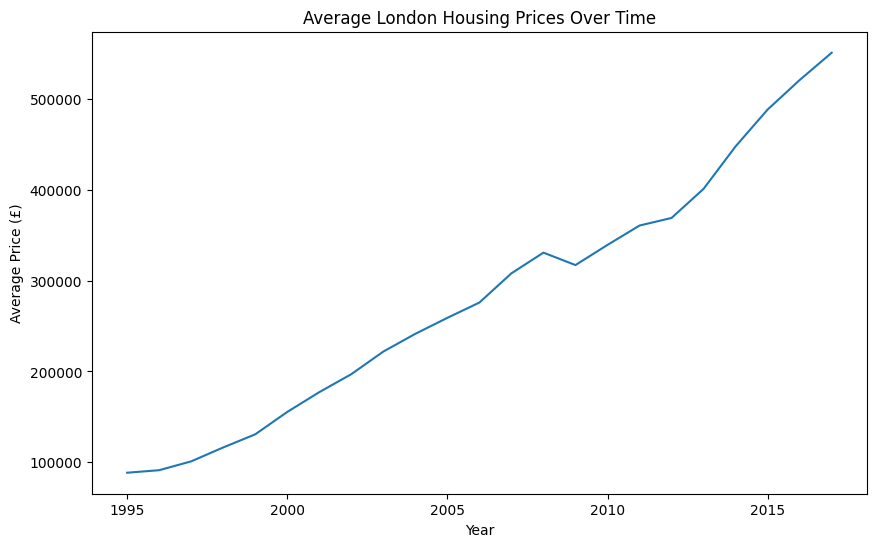

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

yearly_prices.plot()

plt.title("Average London Housing Prices Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price (£)")

plt.show()

In [25]:
borough_prices = df_mean.groupby("area")["value"].mean().sort_values(ascending=False)

borough_prices.head(10)

,value
area,
Kensington and Chelsea,1.009102e+06
Westminster,7.343958e+05
Camden,5.525317e+05
Hammersmith and Fulham,4.991558e+05
City of London,4.510390e+05
Richmond upon Thames,4.476094e+05
Wandsworth,4.025095e+05
Islington,3.972114e+05
Barnet,3.425764e+05


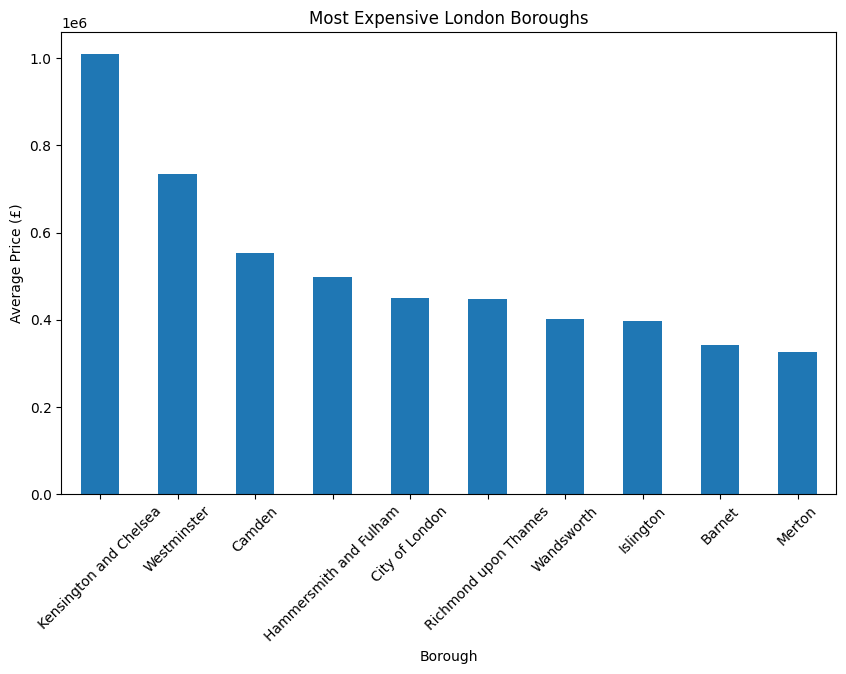

In [26]:
plt.figure(figsize=(10,6))

borough_prices.head(10).plot(kind="bar")

plt.title("Most Expensive London Boroughs")
plt.xlabel("Borough")
plt.ylabel("Average Price (£)")

plt.xticks(rotation=45)

plt.show()